In [26]:
#Import lib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
#Load dataset
orders = pd.read_csv('orders.csv')
items = pd.read_csv('order_items.csv')
products = pd.read_csv('products.csv')

In [29]:
orders = pd.read_csv('orders.csv')
items = pd.read_csv('order_items.csv')
products = pd.read_csv('products.csv')

In [30]:
#Dataset Merge
df = orders.merge(
    items,
    on='order_id'
)
df = df.merge(
    products,
    on='product_id'
)

In [31]:
#Data Understanding
# Shape
orders.shape
items.shape
products.shape

(32951, 9)

In [32]:
# Info
orders.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [33]:
items.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [34]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [35]:
#describe
orders.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [36]:
items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [37]:
products.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [38]:
#Data handling- Check dublicate value
orders.duplicated().sum()

np.int64(0)

In [39]:
items.duplicated().sum()

np.int64(0)

In [40]:
products.duplicated().sum()

np.int64(0)

In [41]:
#check missing value
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [42]:
items.isnull().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [43]:
products.isnull().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [21]:
#Remove rows with missing values and Save cleaned data permanently
orders = orders.dropna()  # Remove rows with missing values
orders.to_csv("orders_cleaned.csv", index=False)  # Save cleaned data permanently

In [44]:
products = products.dropna()
products.to_csv("products_cleaned.csv", index=False)

In [22]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0


In [45]:
products.isnull().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


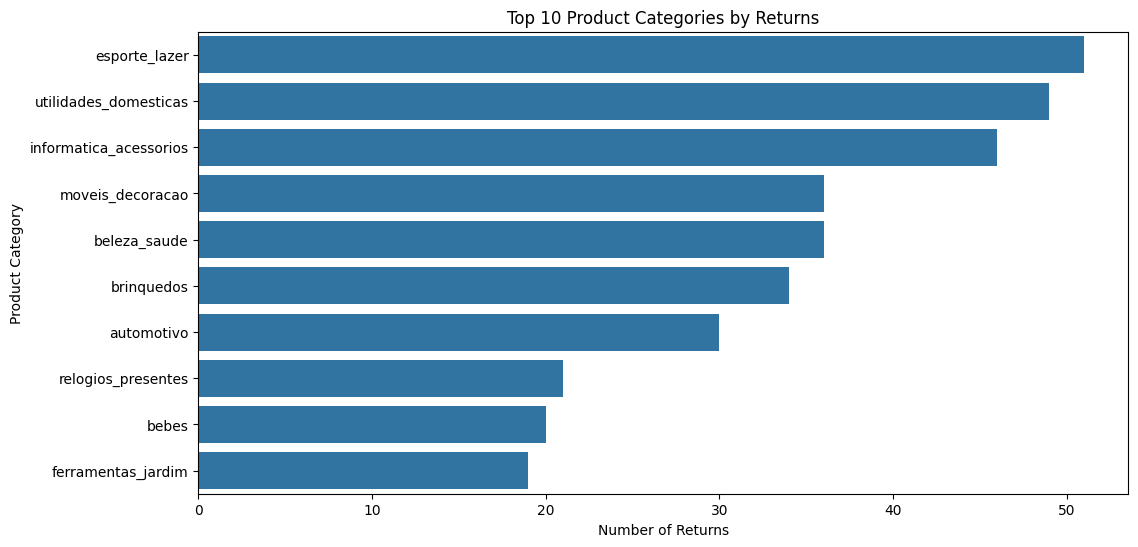

In [46]:
#Exploratory Data Analysis (EDA)

# Qu:1 - Which product categories generate the highest number of returns?

# Filter returned/cancelled orders
returns = df[df['order_status'] == 'canceled']

# Get top returned categories
top_returns = returns['product_category_name'].value_counts().head(10)

# Plot
plt.figure(figsize=(12,6))
sns.countplot(
    data=returns,
    y='product_category_name',
    order=top_returns.index
)

plt.title('Top 10 Product Categories by Returns')
plt.xlabel('Number of Returns')
plt.ylabel('Product Category')
plt.show()

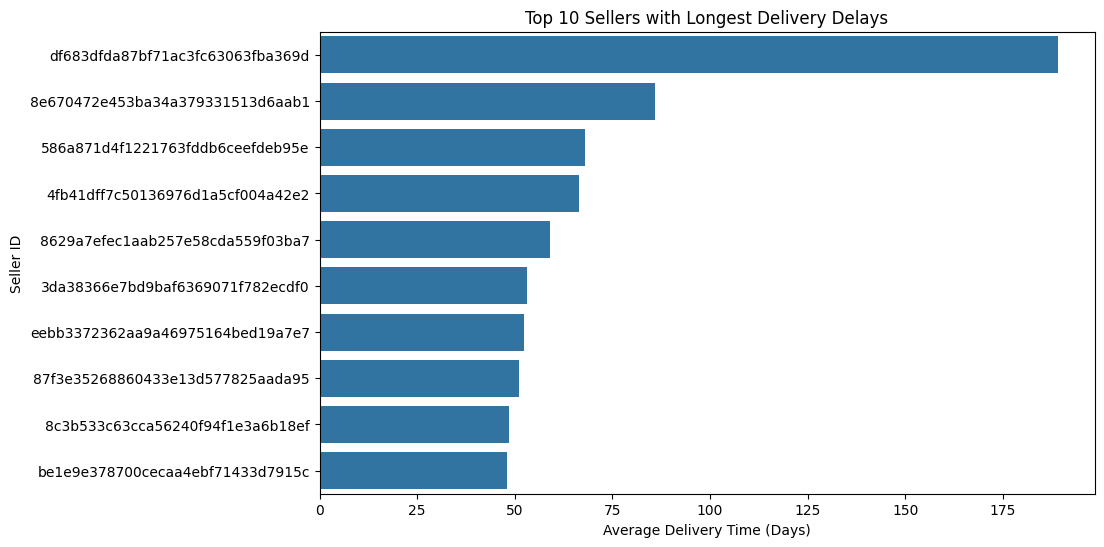

In [47]:
#Qu:2 - Which warehouses experience the longest delays? Metric:Delivery_Time = Delivery_Date - Purchase_Date


df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

df['Delivery_Time'] = (
    df['order_delivered_customer_date'] -
    df['order_purchase_timestamp']
).dt.days

seller_delays = (
    df.groupby('seller_id')['Delivery_Time']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(x=seller_delays.values, y=seller_delays.index)
plt.title('Top 10 Sellers with Longest Delivery Delays')
plt.xlabel('Average Delivery Time (Days)')
plt.ylabel('Seller ID')
plt.show()

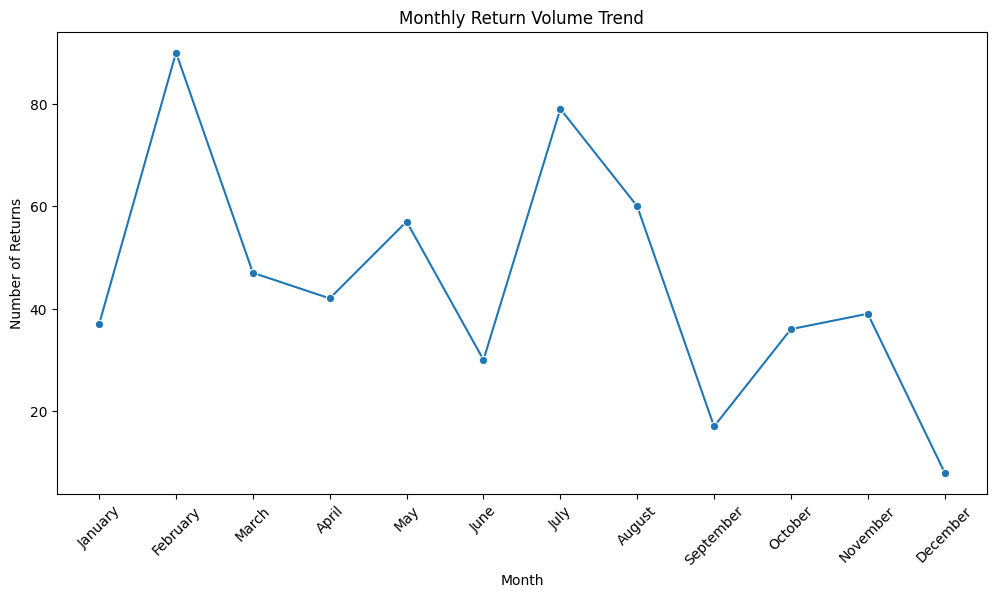

In [48]:
#Qu:3 - Which months have the highest return volumes?

# Filter returned/cancelled orders
returns = df[df['order_status'] == 'canceled'].copy()

# Extract month
returns['Month'] = pd.to_datetime(
    returns['order_purchase_timestamp']
).dt.month_name()

# Count returns per month
monthly_returns = returns['Month'].value_counts().reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]).fillna(0)

# Plot Monthly Trend Analysis
plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_returns.index, y=monthly_returns.values, marker='o')

plt.title('Monthly Return Volume Trend')
plt.xlabel('Month')
plt.ylabel('Number of Returns')
plt.xticks(rotation=45)
plt.show()

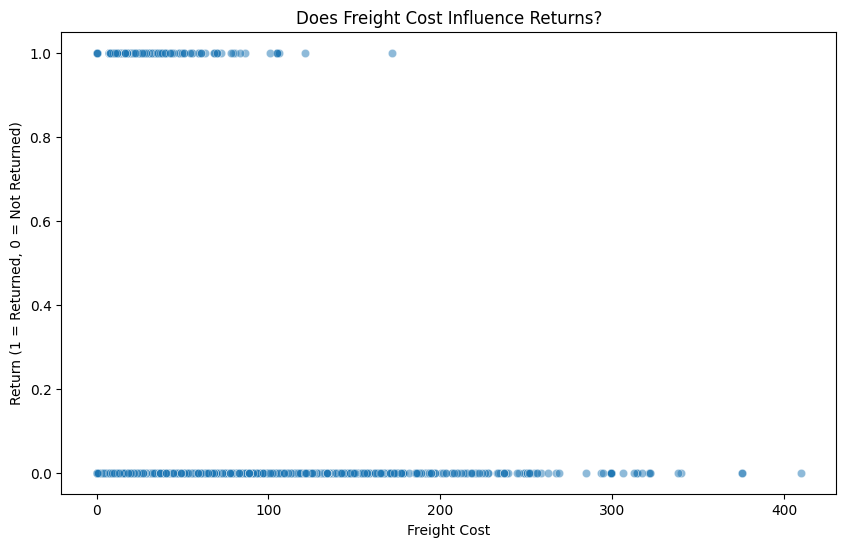

In [49]:
#Qu:4 - Does freight cost influence returns? Create: Scatter Plot

# Create return flag
df['Returned'] = (df['order_status'] == 'canceled').astype(int)

# Scatter Plot: Freight Cost vs Returns
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='freight_value',
    y='Returned',
    alpha=0.5
)

plt.title('Does Freight Cost Influence Returns?')
plt.xlabel('Freight Cost')
plt.ylabel('Return (1 = Returned, 0 = Not Returned)')
plt.show()

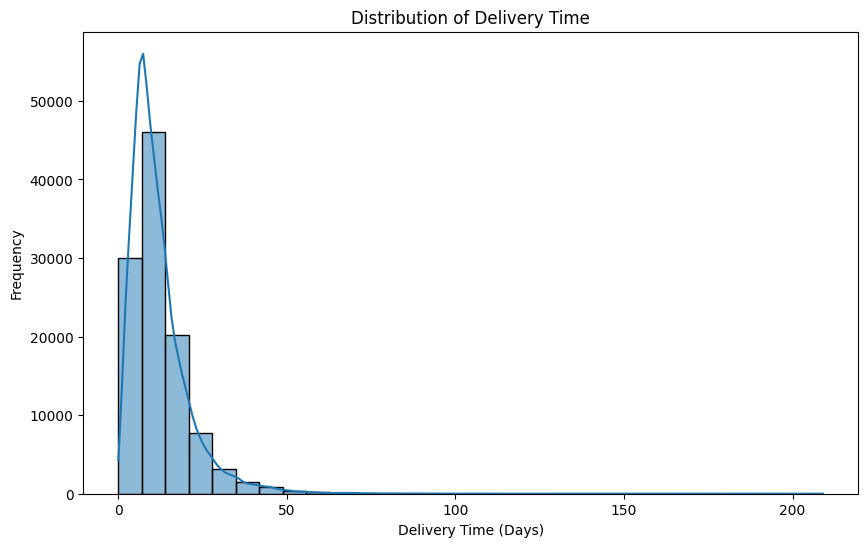

In [50]:
# Basic - Histogram

df['Delivery_Time'] = (
    pd.to_datetime(df['order_delivered_customer_date']) -
    pd.to_datetime(df['order_purchase_timestamp'])
).dt.days

plt.figure(figsize=(10,6))
sns.histplot(df['Delivery_Time'], bins=30, kde=True)

plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Time (Days)')
plt.ylabel('Frequency')
plt.show()

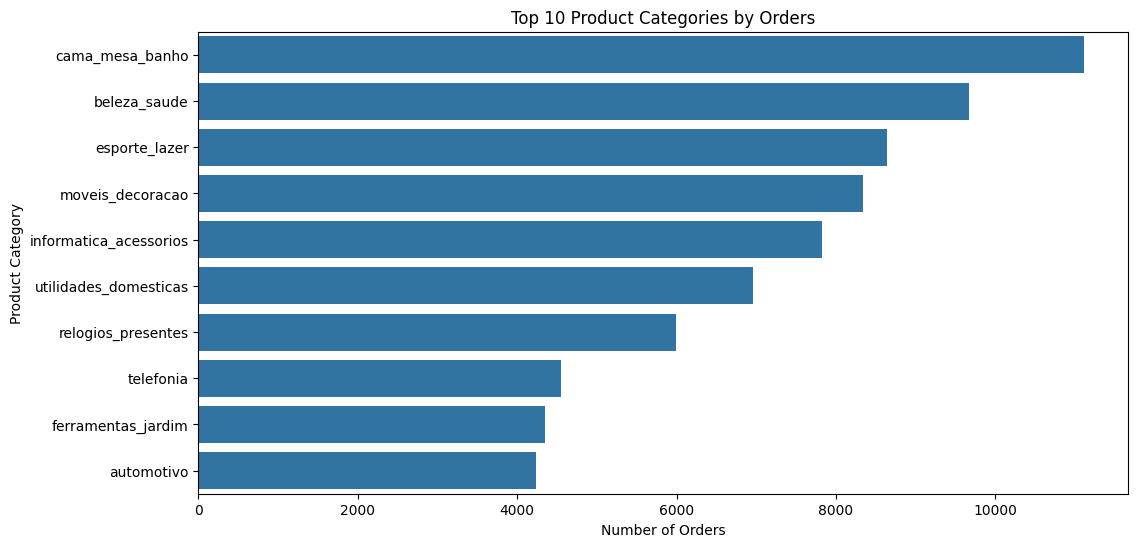

In [51]:
# Basic - Bar chat
top_categories = df['product_category_name'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_categories.values, y=top_categories.index)

plt.title('Top 10 Product Categories by Orders')
plt.xlabel('Number of Orders')
plt.ylabel('Product Category')
plt.show()

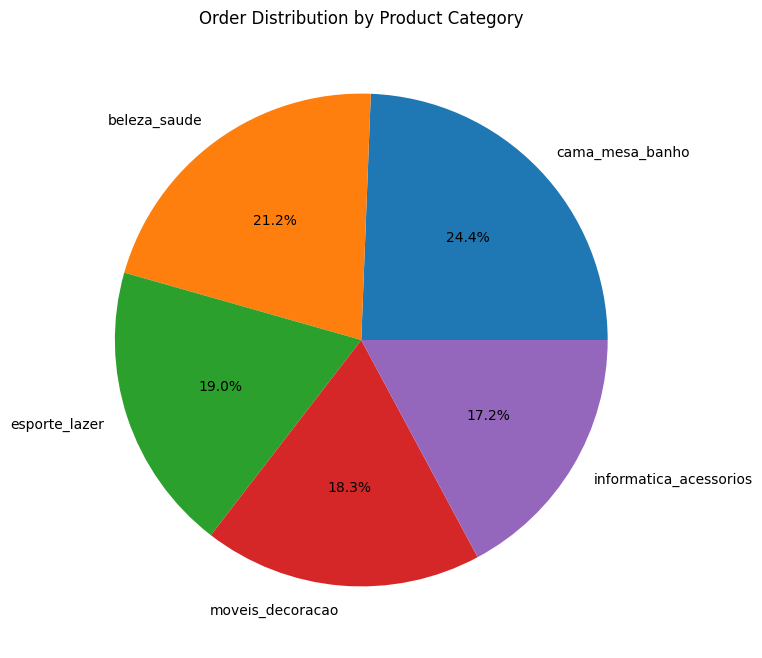

In [52]:
#Basic - Pie Chart

top_categories = df['product_category_name'].value_counts().head(5)

plt.figure(figsize=(8,8))
plt.pie(
    top_categories.values,
    labels=top_categories.index,
    autopct='%1.1f%%'
)

plt.title('Order Distribution by Product Category')
plt.show()

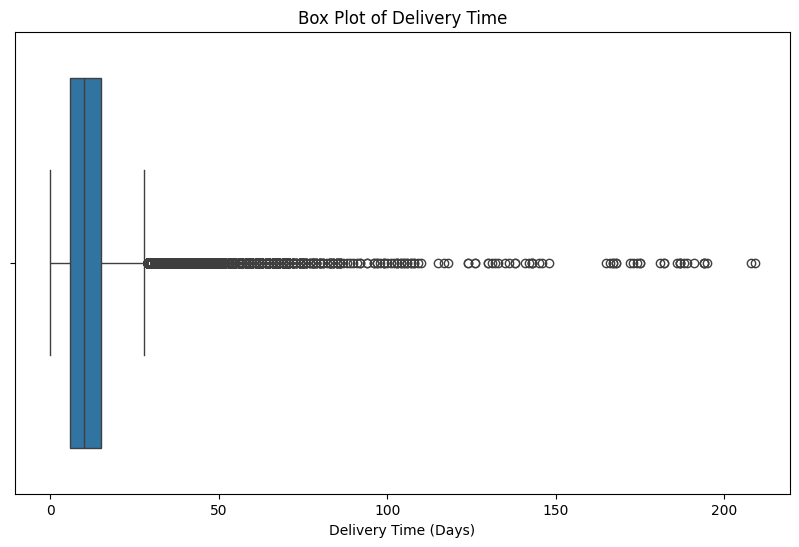

In [53]:
#Intermediate - Box Plot

df['Delivery_Time'] = (
    pd.to_datetime(df['order_delivered_customer_date']) -
    pd.to_datetime(df['order_purchase_timestamp'])
).dt.days

plt.figure(figsize=(10,6))
sns.boxplot(x=df['Delivery_Time'])

plt.title('Box Plot of Delivery Time')
plt.xlabel('Delivery Time (Days)')
plt.show()

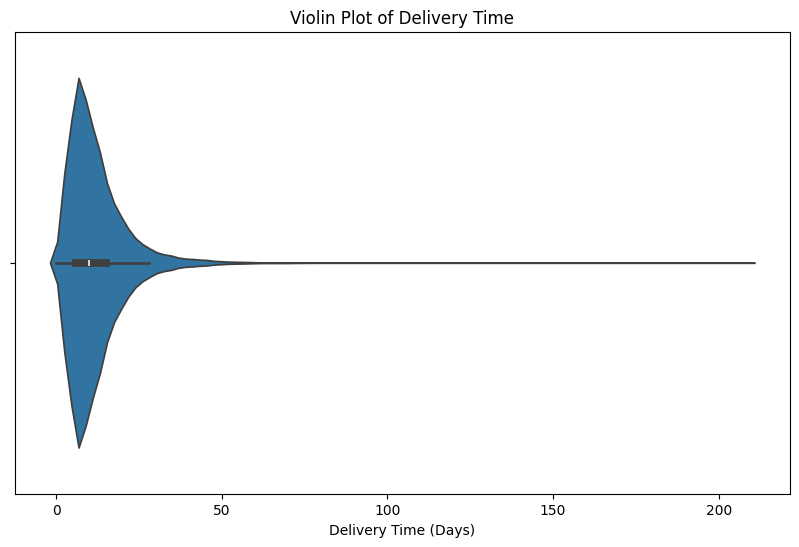

In [54]:
#Intermediate - Violin Plot

df['Delivery_Time'] = (
    pd.to_datetime(df['order_delivered_customer_date']) -
    pd.to_datetime(df['order_purchase_timestamp'])
).dt.days

plt.figure(figsize=(10,6))
sns.violinplot(x=df['Delivery_Time'])

plt.title('Violin Plot of Delivery Time')
plt.xlabel('Delivery Time (Days)')
plt.show()

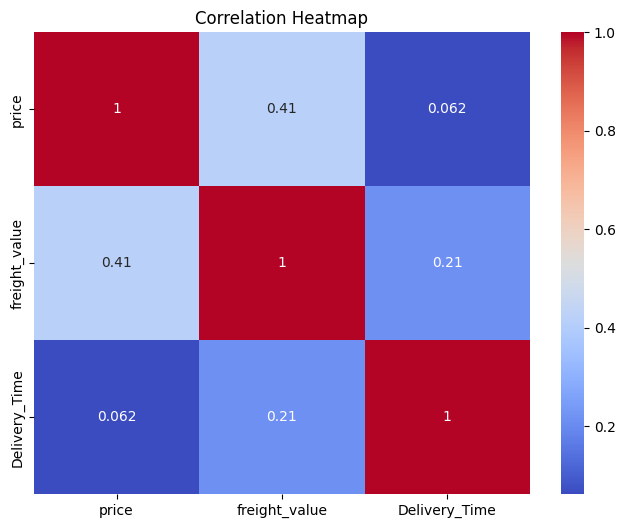

In [55]:
#Intermediate - Heatmap

df['Delivery_Time'] = (
    pd.to_datetime(df['order_delivered_customer_date']) -
    pd.to_datetime(df['order_purchase_timestamp'])
).dt.days

plt.figure(figsize=(8,6))

sns.heatmap(
    df[['price', 'freight_value', 'Delivery_Time']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

In [56]:
import os

folders = [
    "Ecommerce_SupplyChain_Project/data",
    "Ecommerce_SupplyChain_Project/notebooks",
    "Ecommerce_SupplyChain_Project/scripts",
    "Ecommerce_SupplyChain_Project/outputs",
    "Ecommerce_SupplyChain_Project/visualizations",
    "Ecommerce_SupplyChain_Project/presentation",
    "Ecommerce_SupplyChain_Project/ieee_report"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

open("Ecommerce_SupplyChain_Project/README.md", "w").close()

In [57]:
!zip -r Ecommerce_SupplyChain_Project.zip Ecommerce_SupplyChain_Project

  adding: Ecommerce_SupplyChain_Project/ (stored 0%)
  adding: Ecommerce_SupplyChain_Project/visualizations/ (stored 0%)
  adding: Ecommerce_SupplyChain_Project/README.md (stored 0%)
  adding: Ecommerce_SupplyChain_Project/presentation/ (stored 0%)
  adding: Ecommerce_SupplyChain_Project/data/ (stored 0%)
  adding: Ecommerce_SupplyChain_Project/notebooks/ (stored 0%)
  adding: Ecommerce_SupplyChain_Project/outputs/ (stored 0%)
  adding: Ecommerce_SupplyChain_Project/scripts/ (stored 0%)
  adding: Ecommerce_SupplyChain_Project/ieee_report/ (stored 0%)


In [58]:
from google.colab import files

files.download('Ecommerce_SupplyChain_Project.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>